---
title: STATS 3DA3
subtitle: Homework Assignment 6
author: "Henry Nguyen 400475938"
date: 04/16/2025
format: pdf
header-includes:
   - \usepackage{amsmath}
   - \usepackage{bbm}
   - \usepackage{array}
   - \usepackage{multirow}
   - \usepackage{graphicx}
   - \usepackage{float}
   - \usepackage{apacite}
   - \usepackage{natbib}
execute: 
  echo: true
fontsize: 11pt
geometry: margin = 1in
linestretch: 1.5
---

\newpage

## Heart Disease Classification Challenge

### Overview

We will analyze the UCI Heart Disease Dataset, which contains medical records used to predict the presence of heart disease in patients. The dataset includes a mix of categorical and numerical variables, some missing values, and class imbalance.  

For the context of data science methods for heart disease prediction, refer to 
- Detrano, R., et., al. (1989). International application of a new probability algorithm for the diagnosis of coronary artery disease. The American journal of cardiology, 64(5), 304-310. DOI:[10.1016/0002-9149(89)90524-9](https://doi.org/10.1016/0002-9149(89)90524-9).

### Dataset Information 

The dataset is available at the UCI Machine Learning Repository:  
🔗 [https://archive.ics.uci.edu/ml/datasets/Heart+Disease](https://archive.ics.uci.edu/ml/datasets/Heart+Disease) 

In [ ]:
#libraries
from ucimlrepo import fetch_ucirepo 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.cm as cm

from sklearn import svm
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, silhouette_samples, silhouette_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression,LogisticRegressionCV


ModuleNotFoundError: No module named 'ucimlrepo'

In [35]:
# fetch dataset 
heart_disease = fetch_ucirepo(id=45) 
  
# data (as pandas dataframes) 
data = heart_disease.data.original

### 1. 

Our goal is to predict the presence of heart disease using the UCIML Heart Disease dataset. We will be doing a binary classification with (0) as the absence of heart disease and (1) as the presence of heart disease.


### 2. 

Many of our methods will require standardization as they are sensitive to scale (KMeans, logistic regression, SVM). Additionally we will need to use one-hot encoding for our categorical variables as many of them have no natural ordering or consistent spacing between categories (such as thal). However we will save these for after our EDA as to not skew any results.

### 3. 

In [36]:
data.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.300,3,0.000,6.000,0
1,67,1,4,160,286,0,2,108,1,1.500,2,3.000,3.000,2
2,67,1,4,120,229,0,2,129,1,2.600,2,2.000,7.000,1
3,37,1,3,130,250,0,0,187,0,3.500,3,0.000,3.000,0
4,41,0,2,130,204,0,2,172,0,1.400,1,0.000,3.000,0


In [37]:
#dtypes
data.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
num           int64
dtype: object

In [38]:
#Summary statistics
summary = data.describe()
pd.set_option('display.float_format', '{:.3f}'.format)
summary

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,303.000,303.000,303.000,303.000,303.000,303.000,303.000,303.000,303.000,303.000,303.000,299.000,301.000,303.000
mean,54.439,0.680,3.158,131.690,246.693,0.149,0.990,149.607,0.327,1.040,1.601,0.672,4.734,0.937
std,9.039,0.467,0.960,17.600,51.777,0.356,0.995,22.875,0.470,1.161,0.616,0.937,1.940,1.229
min,29.000,0.000,1.000,94.000,126.000,0.000,0.000,71.000,0.000,0.000,1.000,0.000,3.000,0.000
25%,48.000,0.000,3.000,120.000,211.000,0.000,0.000,133.500,0.000,0.000,1.000,0.000,3.000,0.000
50%,56.000,1.000,3.000,130.000,241.000,0.000,1.000,153.000,0.000,0.800,2.000,0.000,3.000,0.000
75%,61.000,1.000,4.000,140.000,275.000,0.000,2.000,166.000,1.000,1.600,2.000,1.000,7.000,2.000
max,77.000,1.000,4.000,200.000,564.000,1.000,2.000,202.000,1.000,6.200,3.000,3.000,7.000,4.000


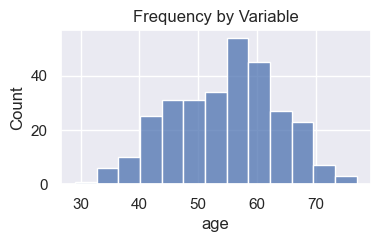

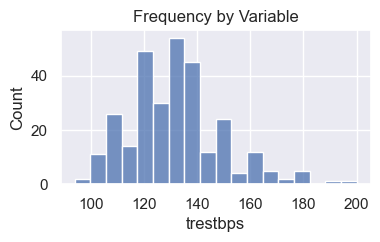

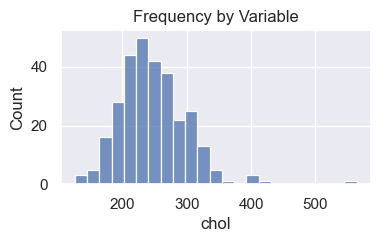

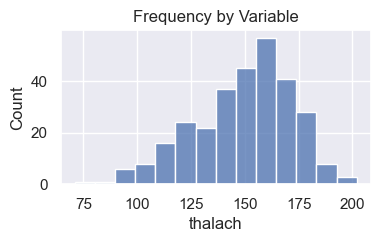

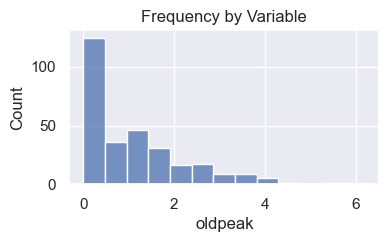

In [97]:
#distribution of numerical variables
numerical = ['age','trestbps','chol','thalach','oldpeak']

for var in numerical:
    plt.figure(figsize=(4, 2))
    sns.histplot(
    data=data,
    x = var,
    )
    plt.title('Frequency by Variable')
    plt.show()

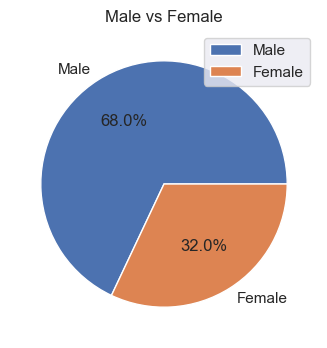

In [103]:
#distribution of sex
data['sex'].value_counts()
maleprop=206/303
femaleprop=97/303
plt.figure(figsize=(8, 4))
plt.pie([maleprop,femaleprop],labels=['Male','Female'],autopct='%1.1f%%')
plt.title('Male vs Female')
plt.legend()

In [41]:
counts = data['num'].value_counts()
counts

num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

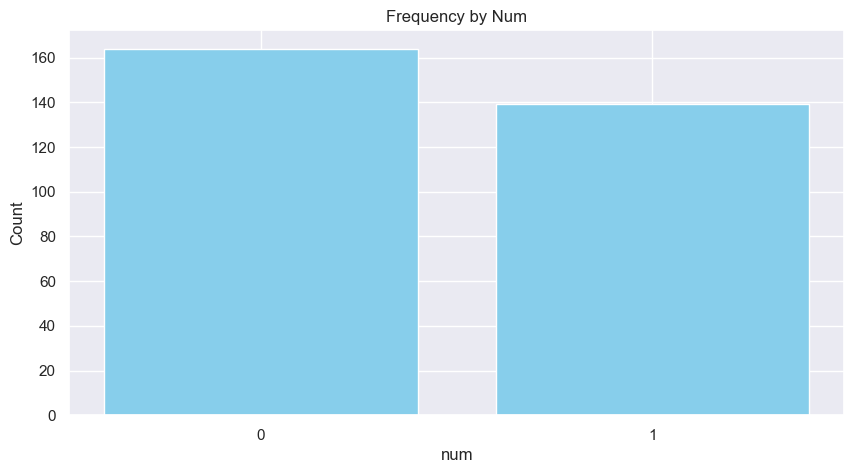

In [84]:
neg = 164
pos = 55 + 36 + 35 + 13
#distribution of num
plt.figure(figsize=(10, 5))
plt.bar(
height=[neg,pos],
x = ['0','1'],
color='skyblue'
)
plt.title('Frequency by Num')
plt.xlabel('num')
plt.ylabel('Count')
plt.show()

Our dataset contains 303 instances with 14 variables:  
- age  
- sex (Male=1, Female=0)  
- cp (1 = typical angina; 2 = atypical angina; 3 = non-anginal pain; 4 = asymptomatic)  
- trestbps (resting blood pressure)  
- chol (serum cholestoral in mg/dl)  
- fbs (fasting blood sugar > 120 mg/dl, 1 = true; 0 = false)
- restecg (resting electrocardiographic results)  
- thalach (maximum heart rate achieved)  
- exang (exercise induced angina, 1 = yes; 0 = no)  
- oldpeak (ST depression induced by exercise relative to rest)  
- slope (1 = upsloping; 2 = flat; 3 = downsloping)  
- ca (number of major vessels (0-3))  
- thal (3 = normal; 6 = fixed defect; 7 = reversable defect)  
- num (diagnosis of heart disease, from 0 to 5)  
  
which are all stored as integers except for oldpeak, ca, and thal which are stored as floats. 
We have a median age of 56 with minimum and maximum ages of 29 and 77 respectively. 68% of instances are male while 32% are female. We have relatively balanced diagnosis outcomes (num).


### 4. 

In [43]:
#replace all num with values 1,2,3,4 to 1
data['num']=data['num'].replace(to_replace=[1,2,3,4],value=1)

In [44]:
data.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.300,3,0.000,6.000,0
1,67,1,4,160,286,0,2,108,1,1.500,2,3.000,3.000,1
2,67,1,4,120,229,0,2,129,1,2.600,2,2.000,7.000,1
3,37,1,3,130,250,0,0,187,0,3.500,3,0.000,3.000,0
4,41,0,2,130,204,0,2,172,0,1.400,1,0.000,3.000,0


### 5.

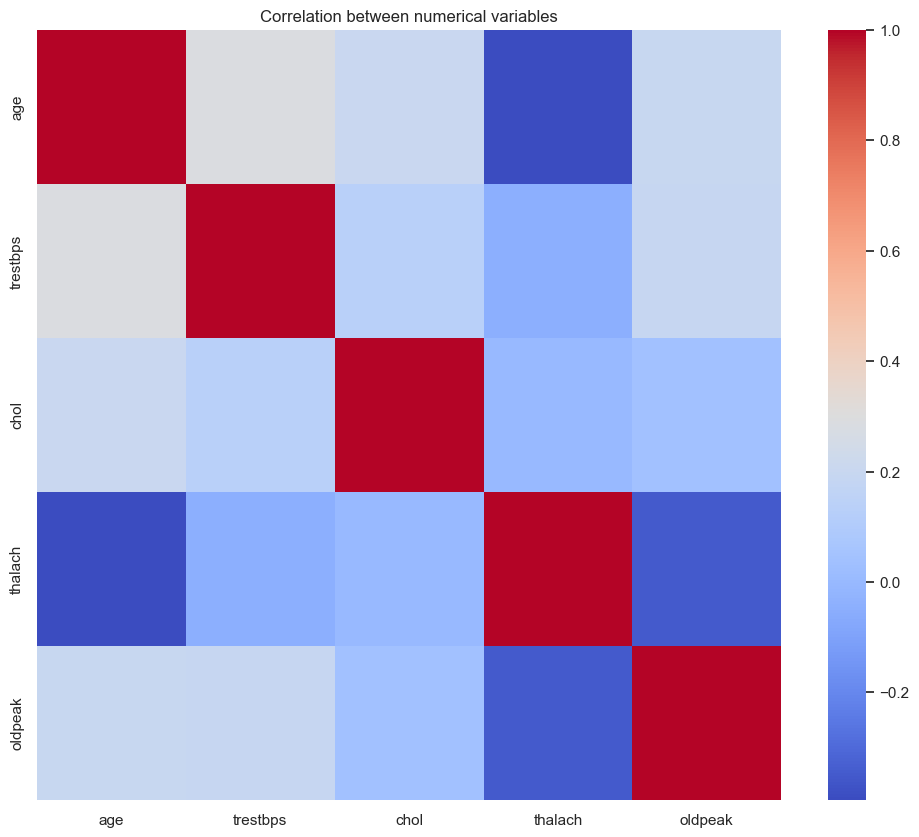

In [78]:
correlation_matrix = data.drop(columns=['sex','cp','fbs','restecg','exang','slope','ca','num','thal']).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt='.2f')
plt.title('Correlation between numerical variables')
plt.show()

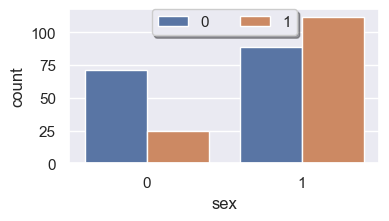

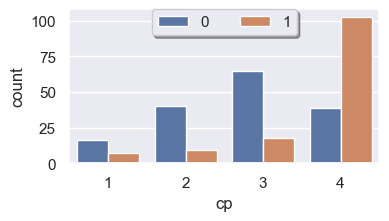

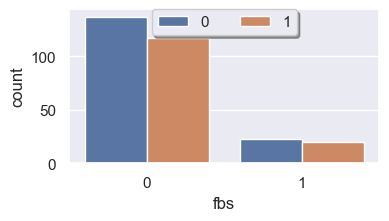

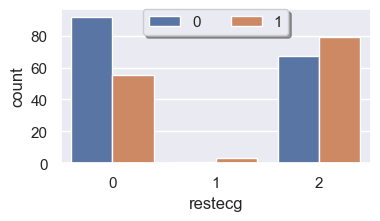

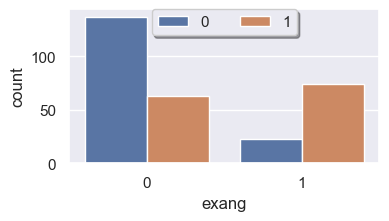

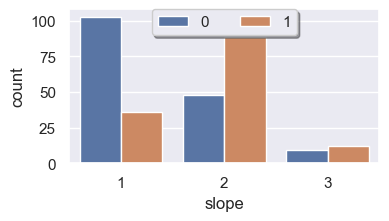

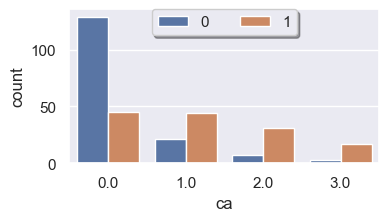

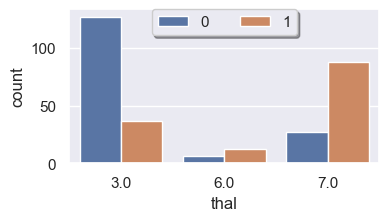

In [102]:
categorable = ['sex','cp','fbs','restecg','exang','slope','ca','thal']
for var in categorable:
    plt.figure(figsize=(4, 2))
    sns.countplot(
        data=data, x=var, hue='num'
    )
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.05),
          ncol=3, fancybox=True, shadow=True)
    plt.show()

We see that the numerical variables seem to be weakly correlated with each other. Categorical variables such as 'cp', 'sex' and 'thal' seem to be good candidates for feature selection with high correlations to the presence of heart disease. We will be using all of them for our preliminary analysis.

### 6. 


In [47]:
#count missing values
data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64

In [48]:
#drop missing values
data=data.dropna()
data.shape

(297, 14)

We see that we have 4 and 2 missing values for the ca and thal variables. We have 297 observations after removing rows with missing values.

### 7. 

In [49]:
data_numerical = data.drop(columns=['sex','cp','fbs','restecg','exang','slope','ca','num','thal'])

In [50]:
data_numerical.head(5)

,age,trestbps,chol,thalach,oldpeak
0,63,145,233,150,2.300
1,67,160,286,108,1.500
2,67,120,229,129,2.600
3,37,130,250,187,3.500
4,41,130,204,172,1.400


In [51]:
#Standardizing numerical data for KMeans
scaler = StandardScaler()
num_norm = pd.DataFrame(
    scaler.fit_transform(data_numerical), 
    index=data_numerical.index, 
    columns=data_numerical.columns
    )

In [52]:
#PCA to reduce dimensionality for visualization
pca_num = PCA()
pca_num.fit(num_norm)
#Fit into dataframe
pca_loadings = pd.DataFrame(
    pca_num.fit(num_norm).components_.T,
    index=num_norm.columns,  
    columns=[f'PC{i+1}' for i in range(pca_num.n_components_)]
)
#Evaluate scores PC scores, fit into dataframe
pca_num.fit_transform(num_norm).shape
pc_scores = pd.DataFrame(
    pca_num.fit_transform(num_norm), 
    index=num_norm.index,
    columns=[f'PC{i+1}' for i in range(pca_num.n_components_)]
    )

c:\Users\hnguy\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\hnguy\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\hnguy\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


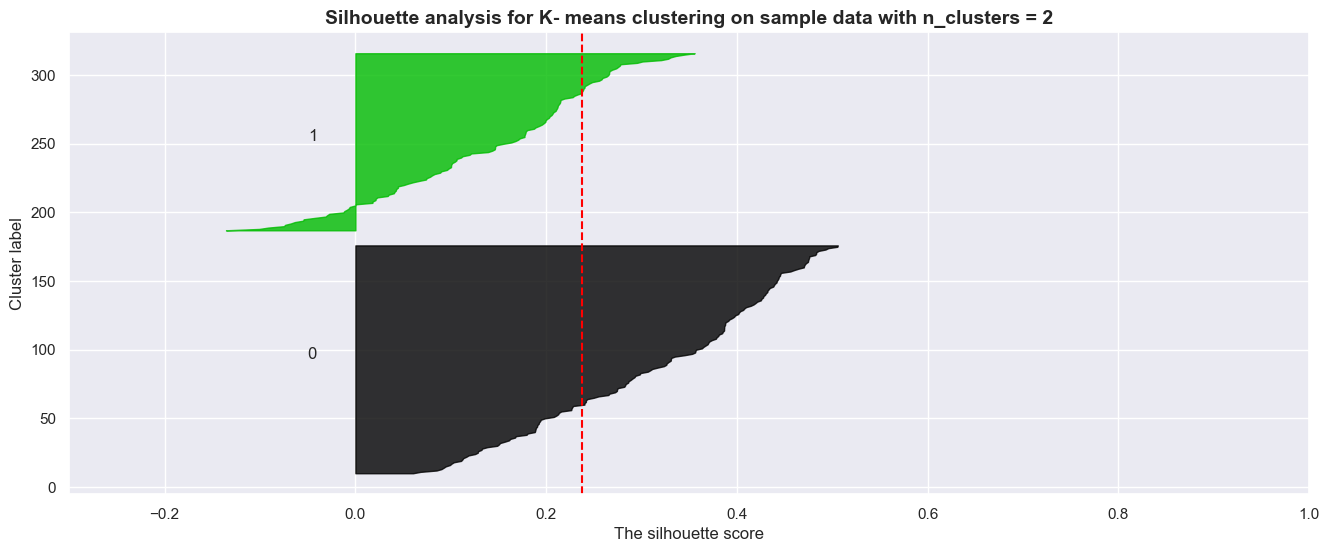

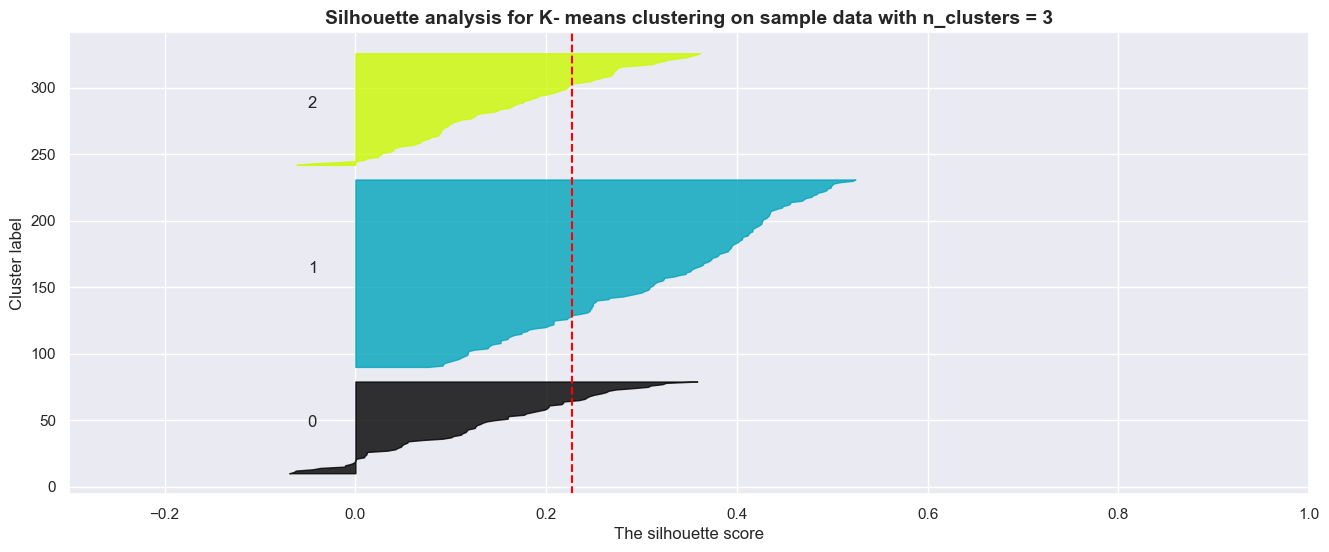

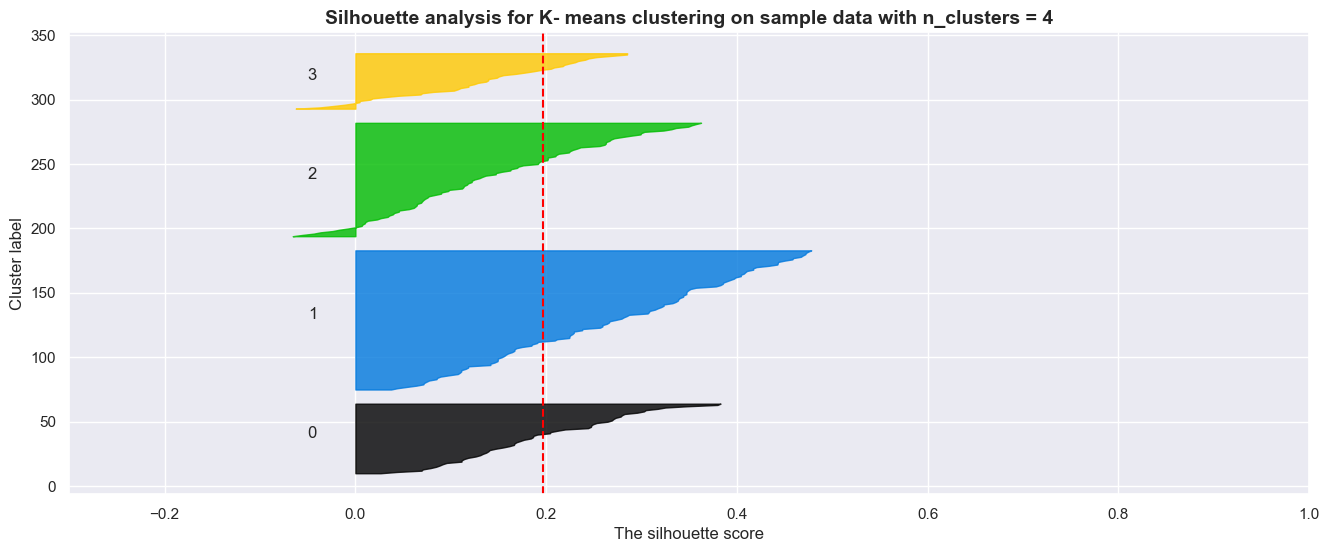

In [95]:
range_n_clusters = [2, 3, 4] #testing for k=2,3,4
for n_clusters in range_n_clusters:
    km = KMeans(n_clusters = n_clusters, n_init = 20, random_state=1)
    cluster_labels_km = km.fit_predict(num_norm)
    # average silhouette score
    silhouette_avg_km = silhouette_score(num_norm, cluster_labels_km)
    # compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(num_norm, cluster_labels_km)
    fig, ax1 = plt.subplots(1, 1)
    fig.set_size_inches(16, 6)
    ax1.set_xlim([-0.3, 1])# change this based on the silhouette range

    y_lower = 10
    
    for i in range(n_clusters):
        # aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels_km == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            y=np.arange(y_lower, y_upper),
            x1=0,
            x2=ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.8,
        )

        # label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next cluster silhouette scores
        y_lower = y_upper + 10  

    ax1.set_title("The silhouette plot for various cluster")
    ax1.set_xlabel("The silhouette score")
    ax1.set_ylabel("Cluster label")

    # vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg_km, color="red", linestyle="--")
    plt.title(
        "Silhouette analysis for K- means clustering on sample data with n_clusters = %d"
        % n_clusters,
        fontsize=14,
        fontweight="bold",
    )

plt.show()

In [54]:
#kmeans with k=2
km = KMeans(n_clusters = 2, n_init = 20, random_state=0)
cluster_labels_km = km.fit_predict(pc_scores)
pc_scores['cluster'] = cluster_labels_km

c:\Users\hnguy\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


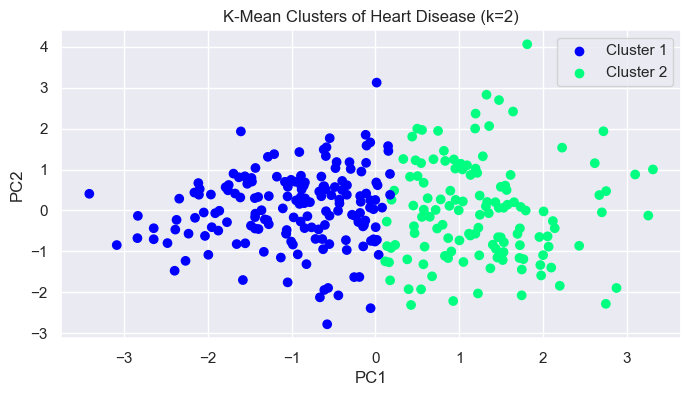

In [ ]:
#visualize the clusters
plt.figure(figsize=(8, 4))
plt.scatter(
    pc_scores['PC1'], 
    pc_scores['PC2'],
    c=pc_scores['cluster'],
    cmap='winter',
    )
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Mean Clusters of Heart Disease (k=2)')
#Dummies for labels
plt.scatter([],[],color='blue',label='Cluster 1')
plt.scatter([],[],color='springgreen',label='Cluster 2')
plt.legend()
plt.show()

In [56]:
pca_loadings[['PC1','PC2']]

,PC1,PC2
age,0.567,0.123
trestbps,0.388,0.419
chol,0.231,0.693
thalach,-0.508,0.469
oldpeak,0.466,-0.330


We use k = 2 for our KMeans as it has the highest average silhouette score. Our KMeans shows 2 linearly seperable groups. PC1 seems to be driven by  age, trestbps, and oldpeak when they are higher, and lowers when thalach is lower.  Our Cluster 1 seems to be younger patients with lower resting blood pressures and ST depression, while Cluster 2 seems to be older patients with higher resting blood pressures and ST depressions. 

### 8. 


In [57]:
X = data.drop(columns='num')
y = data.num

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y)


### 9. 

For the binary classification we have selected SVM and logistic regression as the two classifiers. Both were chosen as our dataset has relatively low in dimensionality mainly numerical features. SVM can also better deal with non-linearity if the need arises. Both are also interpretable which is important in medical contexts. 

### 10. 


We will be using accuracy and the ROC AUC curve.    
  
To calculate accuracy, we use the model to predict the labels using the testing set. We then find the amount of true positives (TP) and true negatives (TN) from the testing set, and compare to our predicted set to find the amount of false positives (FP), and false negatives (FN). Our accuracy is then:  
    
$Accuracy = \tfrac{TP + TN}{TP + TN + FP + FN}$   
  
To calculate our ROC AUC score we use the predicted probabilities our model finds and assign a threshold for for whether to classify that point. We then vary that probability threshold and compare to our test set to find the true positive rate and false positive rate. We plot a curve of TPR vs FPR and the area under the curve is then the ROC AUC score, with 0.5 indicating random guessing.

### 11. 


In [58]:
#Standardization, one-hot encoding preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical),
        ('cat', OneHotEncoder(), categorable)])

In [59]:
#Logistic Model
log1 = Pipeline(steps=[('preprocessor',preprocessor),('logistic',LogisticRegression(max_iter=10000))])
log1.fit(X_train, y_train)

pred_prob_log = log1.predict_proba(X_test)
pred_log = log1.predict(X_test)

In [60]:
#Tuning SVM using gridsearch, linear kernel
SVM1_c = svm.SVC(kernel="linear")
param_grid = {'C': [0.1, 1, 10, 100, 1000]}
# set up the grid search
grid_search = GridSearchCV(
    estimator=SVM1_c, 
    param_grid=param_grid, 
    cv=5, 
    scoring='accuracy'
    )
# do the grid search
grid_search.fit(X_train, y_train)
# best c
SVM1_c_best = grid_search.best_estimator_
print(SVM1_c_best.C)

10


In [61]:
#Fitting SVM
SVM1 = Pipeline(steps=[('preprocessor',preprocessor),('svm',svm.SVC(kernel="linear",C=10,probability=True))])
SVM1.fit(X_train,y_train)

pred_prob_svm = SVM1.predict_proba(X_test)
pred_svm = SVM1.predict(X_test)

### 12. 

In [62]:
#Lasso Tuning for C using Cross Validation
lasso_cv = Pipeline(steps=[('preprocessor',preprocessor),
    ('lasso',LogisticRegressionCV(penalty='l1',solver='saga',cv=5,max_iter=10000,scoring='accuracy'))])

lasso_cv.fit(X_train, y_train)
print(1/lasso_cv.named_steps['lasso'].C_[0])

2.782559402207126


In [63]:
#Lasso Logistic Regression with Optimal C
m_lasso = Pipeline(steps=[('preprocessor',preprocessor),
    ('lasso',LogisticRegression(penalty='l1'
    ,C=lasso_cv.named_steps['lasso'].C_[0],solver='saga',max_iter=10000))])
m_lasso.fit(X_train, y_train) 

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalach', 'oldpeak']),
                                                 ('cat', OneHotEncoder(),
                                                  ['sex', 'cp', 'fbs',
                                                   'restecg', 'exang', 'slope',
                                                   'ca', 'thal'])])),
                ('lasso',
                 LogisticRegression(C=0.3593813663804626, max_iter=10000,
                                    penalty='l1', solver='saga'))])

In [64]:
lasso_pred = m_lasso.predict(X_test)
lasso_pred_prob = m_lasso.predict_proba(X_test)
accuracy_score(y_test, lasso_pred)

0.8777777777777778

In [65]:
#Coefficients for LASSO Logistic Regression
features = m_lasso.named_steps['preprocessor'].get_feature_names_out()
coefficients = m_lasso.named_steps['lasso'].coef_[0]
feature_coefficients = pd.DataFrame({'Feature': features, 'Coefficient': coefficients})
feature_coefficients

,Feature,Coefficient
0,num__age,0.000
1,num__trestbps,0.098
2,num__chol,0.167
3,num__thalach,-0.335
4,num__oldpeak,0.336
5,cat__sex_0,-0.680
6,cat__sex_1,0.273
7,cat__cp_1,0.000
8,cat__cp_2,0.000
9,cat__cp_3,0.000


### 13. 


In [66]:
df_log = pd.DataFrame(
    data = {'prob1': pred_prob_log[:,1], 'y_test': y_test}
    )
df_svm = pd.DataFrame(
    data = {'prob1': pred_prob_svm[:,1], 'y_test': y_test}
    )

df_lasso = pd.DataFrame(
    data = {'prob1': lasso_pred_prob[:,1], 'y_test': y_test}
    )

In [67]:
# calculate false positive rate, true positive rate for logistic regression
log_fpr, log_tpr, thresholds = roc_curve(df_log.y_test, df_log.prob1)

# calculate false positive rate, true positive rate for SVM
svm_fpr, svm_tpr, thresholds = roc_curve(df_svm.y_test, df_svm.prob1)

# calculate false positive rate, true positive rate for LASSO log. regr.
lasso_fpr, lasso_tpr, thresholds = roc_curve(df_lasso.y_test, df_lasso.prob1)

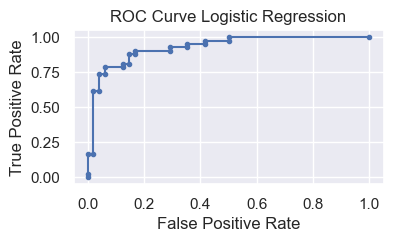

In [68]:
plt.plot(log_fpr, log_tpr, marker='.', label='Logistic')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Logistic Regression')
plt.show()

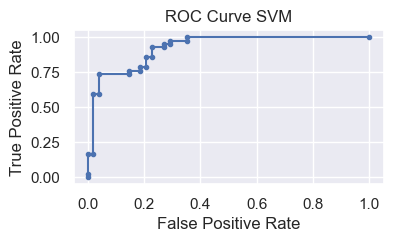

In [69]:
plt.plot(svm_fpr, svm_tpr, marker='.', label='SVM')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve SVM')
plt.show()

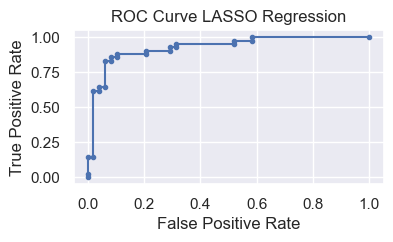

In [70]:
plt.plot(lasso_fpr, lasso_tpr, marker='.', label='Lasso')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve LASSO Regression')
plt.show()

In [71]:
#Displaying ROC AUC scores
log_auc = roc_auc_score(df_log.y_test, df_log.prob1)
svm_auc = roc_auc_score(df_svm.y_test, df_svm.prob1)
lasso_auc = roc_auc_score(df_lasso.y_test, df_lasso.prob1)
print('ROC AUC Logistic Regression: ', log_auc,
    '\n ROC AUC SVM: ', svm_auc,
    '\n ROC AUC Lasso: ',lasso_auc)

ROC AUC Logistic Regression:  0.9280753968253969 
 ROC AUC SVM:  0.9241071428571428 
 ROC AUC Lasso:  0.9270833333333333


In [72]:
#Youden's J statistic for optimal threshold, display sensitivity and specificity
j_statistic_log = log_tpr - log_fpr
optimal_index = np.argmax(j_statistic_log)
optimal_threshold_log = thresholds[optimal_index]
ind_log = np.where(np.isclose(thresholds, optimal_threshold_log, atol=0.001))
print('TPR Logistic: ',log_tpr[ind_log],', TNR Logistic: ',1-log_fpr[ind_log])

j_statistic_svm = svm_tpr - svm_fpr
optimal_index = np.argmax(j_statistic_svm)
optimal_threshold_svm = thresholds[optimal_index]
ind_svm = np.where(np.isclose(thresholds, optimal_threshold_svm, atol=0.001))
print('TPR SVM: ',svm_tpr[ind_svm],', TNR SVM: ',1-svm_fpr[ind_svm])

j_statistic_lasso = lasso_tpr - lasso_fpr
optimal_index = np.argmax(j_statistic_lasso)
optimal_threshold_lasso = thresholds[optimal_index]
ind_lasso = np.where(np.isclose(thresholds, optimal_threshold_lasso, atol=0.001))
print('TPR Lasso: ',lasso_tpr[ind_lasso],', TNR Lasso: ',1-lasso_fpr[ind_lasso])

TPR Logistic:  [0.9047619] , TNR Logistic:  [0.83333333]
TPR SVM:  [0.92857143] , TNR SVM:  [0.77083333]
TPR Lasso:  [0.88095238] , TNR Lasso:  [0.89583333]


In [73]:
#accuracies of models
log_acc = accuracy_score(y_test, pred_log)
svm_acc = accuracy_score(y_test, pred_svm)
lasso_acc = accuracy_score(y_test, lasso_pred)

print('Accuracy by Model: ',
'\n Logistic Regression: ',log_acc,
'\n SVM: ',svm_acc,
'\n Lasso Logistic Regression: ',lasso_acc)

Accuracy by Model:  
 Logistic Regression:  0.8444444444444444 
 SVM:  0.8222222222222222 
 Lasso Logistic Regression:  0.8777777777777778


We see that our logistic, svm, and lasso logistic models have an accuracy of 84.4%, 82.2% and 87.8% respectively. Our LASSO logistic model has the highest accuracy with SVM having the lowest accuracy. Our models have high ROC AUC scores 92.8%, 92.4%, and 92.7% meaning our models can distinguish between heart disease and non heart disease a majority of the time. Our LASSO model has a higher overall accuracy (~3%) with a minor cost to our TPR rate (~2%) but also results in a higher TNR rate (~6%) and a simpler model. 

### 14. 


In [74]:
#coefficients of LASSO model from (12)
feature_coefficients

,Feature,Coefficient
0,num__age,0.000
1,num__trestbps,0.098
2,num__chol,0.167
3,num__thalach,-0.335
4,num__oldpeak,0.336
5,cat__sex_0,-0.680
6,cat__sex_1,0.273
7,cat__cp_1,0.000
8,cat__cp_2,0.000
9,cat__cp_3,0.000


We choose our LASSO logistic regression model as we have less features to track. We see that our most important predictors are cp_4 (1.286), thal_7 (1.256), ca_0 (-1.139), and sex_0 (-0.684). In the context of our classification challenge that means that our most important positive predictors are the presence of asympomatic chest pain and a reversable defect, and our most important negative predictors are no major vessels being colored by fluoroscopy and being female.

\newpage

# References



Janosi, A., Steinbrunn, W., Pfisterer, M., & Detrano, R. (1989). Heart Disease [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C52P4X.